# 22_因果机器学习-DR-Learner 与 R-Learner

## Notebook 使用说明

这是因果学习系列的第 15 份，也是“22. 因果机器学习”的第 5 份。建议先阅读《03. 双重机器学习与交互回归模型》和《04. 条件平均处理效应与元学习器》。本篇需要 NumPy、pandas、Matplotlib、SciPy 和 scikit-learn：`python -m pip install numpy pandas matplotlib scipy scikit-learn`。

主线依据参考资料 [2] 第 15.1 节：DR-Learner 将 AIPW 信号作为回归标签，R-Learner 最小化残差损失。[1] 第 12 章用于对照双重稳健的来源。书中的完整调整变量 $Z$、效应特征子集 $X$，在这里仍按上一篇记为 $X$、$V$；处理 $D$ 记为 $T$。第一阶段始终保留完整调整变量，第二阶段才选定要用哪些变量表达效应。

12 行小表、非线性主模拟、指定辅助误差、低重叠实验和两道练习均为本篇另设的教学构造，不复现原书图中的数值。代码按原书式 (15.1.5)–(15.1.8) 展开；后面的偏差恒等式是对这些公式的代数核对。样条、梯度提升树及软件目标函数的接口依据 [3–5]，不需要 EconML 或 DoubleML。

数据全部由代码生成，不读取外部文件，也不依赖前面 Notebook 的变量。默认采用 5 折交叉拟合，在 600 人和 2,400 人两种样本量下各做 150 次独立训练样本模拟；低重叠部分另做两种机制下各 300 次已知辅助函数模拟。测试数据与画图网格不参与拟合或调参。代码输出和图形均已保存；重新运行请使用 Restart Kernel and Run All Cells，修改参数后以新的输出为准。

In [1]:
# 环境初始化：只生成模拟数据；限制计算线程，不屏蔽模型或数值警告。
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import CenteredNorm
from IPython.display import display
import scipy
from scipy.special import expit
from numpy.polynomial.legendre import leggauss
import sklearn
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 13)
pd.set_option("display.width", 150)
_thread_limit = threadpool_limits(limits=1)

SEED_DATA = 42
SEED_TEST = 2026
SEED_SPLIT = 2026
SEED_REPEAT = 2027
SEED_OVERLAP = 2028
SEED_LEARNER = 99
N_MAIN = 1600
N_TEST = 5000
N_FOLDS = 5
SAMPLE_SIZES = (600, 2400)
N_REPEATS = 150
N_OVERLAP = 2000
N_OVERLAP_REPEATS = 300
CLIP = 0.01

if N_REPEATS < 2 or N_OVERLAP_REPEATS < 2:
    raise ValueError("重复模拟至少需要两次。")
print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"SciPy {scipy.__version__} | scikit-learn {sklearn.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
SciPy 1.17.0 | scikit-learn 1.8.0


上一篇的 S/T/X 都从结果预测出发。两种收入都预测错一点，差值也可能跟着错。现在把前面学过的纠偏步骤接进来：不直接平滑预测差，而是先构造一份带残差纠偏的标签；或者不补全结局，直接用两侧残差拟合效应函数。

这两条路分别得到 DR-Learner 和 R-Learner。它们都使用结果与处理预测，但稳健性并不相同；当最后只允许一条直线或一个常数时，甚至可能在估计不同的量。

## 理论基础

### 1. 先分清调整变量与效应特征

令 $X$ 为完整的处理前调整变量，$V$ 是其中用于报告效应的部分。定义

$$
\delta(X)=E[Y(1)-Y(0)\mid X],\qquad
\tau_V(v)=E[\delta(X)\mid V=v].
$$

在一致性、无干扰、给定 $X$ 的条件可忽略性与相应重叠条件下，

$$
\delta(X)=\mu_1(X)-\mu_0(X),\quad
\mu_t(X)=E[Y\mid T=t,X],\quad e(X)=P(T=1\mid X).
$$

这里没有因为只按 $V$ 报告结果，就从辅助模型中删掉其余混杂变量。[2，第 14.1 节]

### 2. DR-Learner：将 AIPW 的每一行拿来回归

第八份笔记把下面的量求平均，得到 AIPW；现在保留每一行：

$$
\widehat\Gamma_i=
\widehat\mu_1(X_i)-\widehat\mu_0(X_i)
+\frac{T_i\{Y_i-\widehat\mu_1(X_i)\}}{\widehat e(X_i)}
-\frac{(1-T_i)\{Y_i-\widehat\mu_0(X_i)\}}{1-\widehat e(X_i)}.
$$

辅助函数都取真值时，$E[\Gamma\mid X]=\delta(X)$，再对 $V$ 条件平均便得到 $E[\Gamma\mid V]=\tau_V(V)$。因此可以训练一个回归器：输入 $V_i$，标签为 $\widehat\Gamma_i$。

$$
\widehat\tau_{\mathrm{DR}}
=\arg\min_{f\in\mathcal F}\frac1n\sum_i[\widehat\Gamma_i-f(V_i)]^2.
$$

这就是本篇的 DR-Learner。双重稳健来自第一阶段信号；最后的回归仍可能因样本少、模型太简单或过度拟合而有误差。一行 $\widehat\Gamma_i$ 不是被观察到的个人处理效应。[1，第 12.1 节；2，式 (15.1.5)]

## 完整案例一：12 行数据，先核对两种目标函数

下面给定一份小表，以及假想的外部预测。它们不是用这 12 行拟合的，也不假定全部正确。先逐行计算 DR 标签。

In [2]:
tiny = pd.DataFrame({
    "V": np.repeat([-1., 0., 1.], 4),
    "T": [0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1],
})
tiny["e"] = np.repeat([.2, .5, .8], 4)
noise = np.array([.2, -.1, .3, -.2, -.3, .1, .2, -.1, .2, -.2, .1, .3])
tiny["Y"] = 2+tiny["V"] + tiny["T"]*(1+.5*tiny["V"]) + noise
# 外部工作预测，和生成数据的条件均值有少量差别。
tiny["mu0_hat"] = 2+tiny["V"]+.2
tiny["mu1_hat"] = 3+1.5*tiny["V"]+.1
tiny["ell_hat"] = 2+tiny["V"]+tiny["e"]*(1+.5*tiny["V"])+.15
tiny["预测差"] = tiny["mu1_hat"]-tiny["mu0_hat"]
tiny["处理纠偏"] = tiny["T"]*(tiny["Y"]-tiny["mu1_hat"])/tiny["e"]
tiny["对照纠偏"] = (1-tiny["T"])*(tiny["Y"]-tiny["mu0_hat"])/(1-tiny["e"])
tiny["Gamma"] = tiny["预测差"]+tiny["处理纠偏"]-tiny["对照纠偏"]
display(tiny[["V", "T", "Y", "e", "预测差", "处理纠偏", "对照纠偏", "Gamma"]].round(4))

,V,T,Y,e,预测差,处理纠偏,对照纠偏,Gamma
0,-1.0,0,1.2,0.2,0.4,-0.000,0.000,0.400
1,-1.0,0,0.9,0.2,0.4,-0.000,-0.375,0.775
2,-1.0,0,1.3,0.2,0.4,-0.000,0.125,0.275
3,-1.0,1,1.3,0.2,0.4,-1.500,0.000,-1.100
4,0.0,0,1.7,0.5,0.9,-0.000,-1.000,1.900
5,0.0,0,2.1,0.5,0.9,-0.000,-0.200,1.100
6,0.0,1,3.2,0.5,0.9,0.200,0.000,1.100
7,0.0,1,2.9,0.5,0.9,-0.400,0.000,0.500
8,1.0,0,3.2,0.8,1.4,-0.000,0.000,1.400
9,1.0,1,4.3,0.8,1.4,-0.375,0.000,1.025


第一个处理者的评分为 0.2，因此其结果残差被放大五倍。这一步在均值上纠偏，也会放大噪声；“双重稳健”不等于每行标签都更准确。

### 3. R-Learner：用残差拟合一个变化的斜率

另定义 $\ell(X)=E[Y\mid X]$。注意它不等于未处理均值 $\mu_0(X)$，而是

$$
\ell(X)=\mu_0(X)+e(X)\delta(X).
$$

两侧残差为 $a_i=Y_i-\widehat\ell(X_i)$、$b_i=T_i-\widehat e(X_i)$。将 PLR 的共同斜率换为函数，便得到

$$
\widehat\tau_R=\arg\min_{f\in\mathcal F}
\frac1n\sum_i[a_i-b_if(V_i)]^2.
$$

若 $b_i\ne0$，同一损失还可以写成

$$
[a_i-b_if(V_i)]^2=b_i^2\left[\frac{a_i}{b_i}-f(V_i)\right]^2.
$$

所以 R-Learner 也能交给通用加权回归器：标签 $q_i=a_i/b_i$，权重 $w_i=b_i^2$。漏掉权重，就换了优化问题。原书式 (15.1.6) 是直接残差形式，式 (15.1.7) 是带除法的等价表示；前者不要求实际计算这个比值。[2，第 15.1 节]

若 $f(v)=\beta_0+\beta_1v$，可以直接用设计矩阵 $[b_i,b_iv_i]$ 回归 $a_i$。这里的 $\beta_0$ 是“效应函数截距”，必须乘上 $b_i$；不能再额外加一列未乘残差的常数。

In [3]:
a_tiny = (tiny["Y"]-tiny["ell_hat"]).to_numpy()
b_tiny = (tiny["T"]-tiny["e"]).to_numpy()
q_tiny, w_tiny = a_tiny/b_tiny, b_tiny**2
phi_tiny = np.column_stack([np.ones(len(tiny)), tiny["V"]])
coef_dr_tiny = np.linalg.lstsq(phi_tiny, tiny["Gamma"], rcond=None)[0]
coef_r_tiny = np.linalg.lstsq(b_tiny[:, None]*phi_tiny, a_tiny, rcond=None)[0]
coef_wls_tiny = LinearRegression(fit_intercept=False).fit(
    phi_tiny, q_tiny, sample_weight=w_tiny).coef_
coef_unweighted = LinearRegression(fit_intercept=False).fit(phi_tiny, q_tiny).coef_
np.testing.assert_allclose(coef_r_tiny, coef_wls_tiny, atol=1e-12)

candidate = np.array([.9, .4])
loss_direct = np.mean((a_tiny-b_tiny*(phi_tiny@candidate))**2)
loss_weighted = np.mean(w_tiny*(q_tiny-phi_tiny@candidate)**2)
np.testing.assert_allclose(loss_direct, loss_weighted, atol=1e-12)

display(pd.DataFrame({"V": tiny["V"], "a": a_tiny, "b": b_tiny,
                      "q=a/b": q_tiny, "w=b²": w_tiny}).round(4))
display(pd.DataFrame([coef_dr_tiny, coef_r_tiny, coef_wls_tiny, coef_unweighted],
    index=["DR：普通标签回归", "R：直接残差回归", "R：等价加权回归", "错误对照：忽略权重"],
    columns=["效应截距", "效应斜率"]).round(6))
print(f"同一候选函数的直接损失 = {loss_direct:.8f}；加权损失 = {loss_weighted:.8f}")

,V,a,b,q=a/b,w=b²
0,-1.0,-0.05,-0.2,0.2500,0.04
1,-1.0,-0.35,-0.2,1.7500,0.04
2,-1.0,0.05,-0.2,-0.2500,0.04
3,-1.0,0.05,0.8,0.0625,0.64
4,0.0,-0.95,-0.5,1.9000,0.25
5,0.0,-0.55,-0.5,1.1000,0.25
6,0.0,0.55,0.5,1.1000,0.25
7,0.0,0.25,0.5,0.5000,0.25
8,1.0,-1.15,-0.8,1.4375,0.64
9,1.0,-0.05,0.2,-0.2500,0.04


,效应截距,效应斜率
DR：普通标签回归,0.868750,0.640625
R：直接残差回归,0.916667,0.618421
R：等价加权回归,0.916667,0.618421
错误对照：忽略权重,0.925000,0.359375


同一候选函数的直接损失 = 0.05536667；加权损失 = 0.05536667


两种 R 实现相同，但不要求与 DR 相同。它们使用不同的样本目标函数，有限样本的系数自然可以不同。

若某一行恰有 $b_i=0$，该行的直接损失为 $a_i^2$，与效应函数无关。它不提供这一步的斜率信息，也不应通过随意给分母加一个小数来“制造”信息。本篇的线性／样条 R 实现直接构建设计矩阵；通用加权回归只在分母非零时使用。

## 完整案例二：交叉拟合后，学习一条效应曲线

### 1. 生成数据，但把真值与可用数据分开

下面是本篇的教学模拟。三个协变量独立服从 $U(-1,1)$，指定

$$
\begin{aligned}
e(X)&=\operatorname{expit}(0.4+1.2X_1-0.9X_2+0.5X_3),\\
\mu_0(X)&=2+1.2X_2+0.8X_1^2+0.8X_2^2+0.5X_1X_3,\\
\delta(X)&=0.8+0.8X_1+0.8(X_1^2-1/3).
\end{aligned}
$$

再生成 $T\mid X\sim\operatorname{Bernoulli}(e(X))$ 和

$$
Y=\mu_0(X)+T\delta(X)+\sigma(X,T)\varepsilon,
\quad \sigma(X,T)=0.45+0.15X_2^2+0.15T,
\quad\varepsilon\sim N(0,1).
$$

生成式保证了给定完整 $X$ 后没有未测混杂。这里的真实效应只依赖 $V=X_1$，所以两种方法在正确的最终函数空间内有相同目标。结果与评分模型仍输入三列 $X$，不只输入 $V$。字典 `known` 只用于核对，不传给训练函数。

In [4]:
def true_functions(x):
    x = np.asarray(x, float)
    if x.ndim != 2 or x.shape[1] != 3:
        raise ValueError("主模拟使用三个协变量。")
    x1, x2, x3 = x.T
    e = expit(.4+1.2*x1-.9*x2+.5*x3)
    mu0 = 2+1.2*x2+.8*x1**2+.8*x2**2+.5*x1*x3
    tau = .8+.8*x1+.8*(x1**2-1/3)
    return {"mu0": mu0, "mu1": mu0+tau, "e": e, "tau": tau, "ell": mu0+e*tau}


def make_data(n, seed):
    if not isinstance(n, int) or n < 4:
        raise ValueError("n 必须是至少为 4 的整数。")
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1, 1, (n, 3))
    known = true_functions(x)
    t = rng.binomial(1, known["e"])
    sigma = .45+.15*x[:, 1]**2+.15*t
    y = known["mu0"] + t*known["tau"] + rng.normal(size=n)*sigma
    return {"x": x, "t": t, "y": y}, known

observed, known = make_data(N_MAIN, SEED_DATA)
test_observed, test_known = make_data(N_TEST, SEED_TEST)
x, t, y = observed["x"], observed["t"], observed["y"]
v = x[:, 0]
x_test, v_test = test_observed["x"], test_observed["x"][:, 0]
display(pd.DataFrame(np.column_stack([x, t, y]), columns=["X1", "X2", "X3", "T", "Y"]).head(8).round(4))
print(f"训练样本：{len(y)} 人；对照 {(t == 0).sum()} 人，处理 {(t == 1).sum()} 人。")
print(f"独立测试特征：{len(v_test)} 行；总体 ATE = 0.8。")

,X1,X2,X3,T,Y
0,0.5479,-0.1222,0.7172,1.0,3.1941
1,0.3947,-0.8116,0.9512,1.0,3.6329
2,0.5223,0.5721,-0.7438,1.0,4.1203
3,-0.0992,-0.2584,0.8535,1.0,1.8751
4,0.2877,0.6455,-0.1132,0.0,3.7865
5,-0.5455,0.1092,-0.8724,1.0,3.8850
6,0.6553,0.2633,0.5162,1.0,5.0514
7,-0.2909,0.9414,0.7862,0.0,3.2947


训练样本：1600 人；对照 651 人，处理 949 人。
独立测试特征：5000 行；总体 ATE = 0.8。


### 2. 第一阶段：每行预测都来自其他折

先将训练样本分成五折。在每一折之外拟合 $\widehat\mu_0$、$\widehat\mu_1$、$\widehat e$，另直接回归 $Y$ 对 $X$ 得到 $\widehat\ell$，然后预测留出折。结果回归分别用训练折中的两组数据，$\ell$ 与评分则用整个训练折。[2，备注 15.1.1]

汇总这些折外预测后，DR 与 R 的最终效应模型都使用全部训练行。最终模型对这些训练行的拟合值，不会因为第一阶段用了交叉拟合，就自动成为折外 CATE 预测。测试集从头到尾不进入训练。

下面保留折索引检查；同一人不能同时处于同一折的训练端和预测端。标准化、特征展开也放在各自的训练管线中完成。

In [5]:
def as_vector(a, name):
    a = np.asarray(a, dtype=float)
    if a.ndim != 1 or not np.all(np.isfinite(a)):
        raise ValueError(f"{name} 必须是一维有限数值数组。")
    return a


def check_data(x, t, y):
    x = np.asarray(x, dtype=float)
    t, y = as_vector(t, "T"), as_vector(y, "Y")
    if x.ndim != 2 or x.shape[1] == 0 or not np.all(np.isfinite(x)):
        raise ValueError("X 必须是至少含一列的有限数值矩阵。")
    if len(x) != len(t) or len(t) != len(y) or len(y) < 4:
        raise ValueError("X、T、Y 行数必须一致，且至少四行。")
    if not np.array_equal(np.unique(t), [0., 1.]):
        raise ValueError("T 必须同时含 0 和 1。")
    return x, t.astype(int), y


def check_folds(folds, n):
    if len(folds) < 2:
        raise ValueError("交叉拟合至少需要两折。")
    seen = np.zeros(n, dtype=int)
    checked = []
    for tr, te in folds:
        tr, te = np.asarray(tr), np.asarray(te)
        if any(a.ndim != 1 or a.dtype.kind not in "iu" or not len(a) for a in (tr, te)):
            raise ValueError("训练和留出索引必须是非空整数向量。")
        if any(a.min() < 0 or a.max() >= n or len(np.unique(a)) != len(a) for a in (tr, te)):
            raise ValueError("折内索引重复或越界。")
        if len(np.intersect1d(tr, te)) or len(tr)+len(te) != n:
            raise ValueError("每折训练集必须恰为留出集的补集。")
        seen[te] += 1
        checked.append((tr, te))
    if not np.all(seen == 1):
        raise ValueError("每行必须且只能被留出预测一次。")
    return checked


def crossfit_nuisances(x, t, y, regressor, propensity, *, folds=None, n_folds=5,
                       seed=2026, clip=0.01, store_models=False):
    x, t, y = check_data(x, t, y)
    if not 0 < clip < .5:
        raise ValueError("clip 必须介于 0 与 0.5。")
    if folds is None:
        if not isinstance(n_folds, int) or not 2 <= n_folds <= np.bincount(t).min():
            raise ValueError("折数不能超过较少处理组的人数。")
        folds = list(StratifiedKFold(n_folds, shuffle=True, random_state=seed).split(x, t))
    folds = check_folds(folds, len(y))
    out = {name: np.full(len(y), np.nan) for name in ("mu0", "mu1", "ell", "e_raw")}
    fold_id = np.full(len(y), -1, dtype=int)
    audit, saved = [], []
    for k, (tr, te) in enumerate(folds):
        if np.unique(t[tr]).size != 2:
            raise ValueError("每个训练折都必须有两种处理。")
        fitted = {}
        for arm in (0, 1):
            arm_idx = tr[t[tr] == arm]
            fitted[f"mu{arm}"] = clone(regressor).fit(x[arm_idx], y[arm_idx])
            out[f"mu{arm}"][te] = fitted[f"mu{arm}"].predict(x[te])
        fitted["ell"] = clone(regressor).fit(x[tr], y[tr])
        fitted["e"] = clone(propensity).fit(x[tr], t[tr])
        out["ell"][te] = fitted["ell"].predict(x[te])
        classes = np.asarray(fitted["e"].classes_)
        if not np.array_equal(classes, [0, 1]):
            raise ValueError("评分分类器的类别必须是 0、1。")
        out["e_raw"][te] = fitted["e"].predict_proba(x[te])[:, 1]
        fold_id[te] = k
        audit.append({"折": k+1, "训练对照": int(sum(t[tr] == 0)),
                      "训练处理": int(sum(t[tr] == 1)), "留出人数": len(te),
                      "索引交集": len(np.intersect1d(tr, te))})
        if store_models:
            saved.append(fitted)
    if not all(np.isfinite(a).all() for a in out.values()):
        raise FloatingPointError("有未完成或非有限的折外预测。")
    if np.any((out["e_raw"] < 0) | (out["e_raw"] > 1)):
        raise ValueError("predict_proba 返回了区间外的值。")
    out["e"] = np.clip(out["e_raw"], clip, 1-clip)
    out.update({"fold_id": fold_id, "folds": folds, "audit": pd.DataFrame(audit),
                "n_clipped": int(np.count_nonzero(out["e"] != out["e_raw"])), "models": saved})
    return out

### 3. 看一遍实际的折外预测

先用三次多项式展开后的岭回归作为辅助结果模型，评分用 Logistic 回归。$\mu_0$、$\mu_1$ 的真实函数在这个展开空间中，但有限样本拟合仍有误差和收缩；$\ell$ 含有 Logistic 概率与效应的乘积，只是由多项式近似，不把它叫作“完全正确的模型”。

为了防止数值除零，估计评分显式限制在 $[0.01,0.99]$，并报告受影响行数。这个操作不是修复真实重叠；后面的已知评分实验不使用此限制。

In [6]:
def regressors(kind):
    if kind in ("linear", "cubic"):
        degree = 1 if kind == "linear" else 3
        return make_pipeline(PolynomialFeatures(degree, include_bias=False),
                             StandardScaler(), Ridge(alpha=1., solver="cholesky"))
    if kind == "boost":
        return HistGradientBoostingRegressor(max_iter=120, max_leaf_nodes=12,
            min_samples_leaf=25, learning_rate=.08, l2_regularization=1.,
            early_stopping=False, random_state=SEED_LEARNER)
    raise ValueError("未知回归器。")


def propensity_model():
    return make_pipeline(StandardScaler(), LogisticRegression(C=100., max_iter=1000, tol=1e-8))

nuisance_main = crossfit_nuisances(x, t, y, regressors("cubic"), propensity_model(),
    n_folds=N_FOLDS, seed=SEED_SPLIT, clip=CLIP, store_models=True)
display(nuisance_main["audit"])
print(f"被截断的评分：{nuisance_main['n_clipped']} / {len(y)}")

fold_preview = pd.DataFrame({"折": nuisance_main["fold_id"]+1, "T": t, "Y": y,
    "mu0_OOF": nuisance_main["mu0"], "mu1_OOF": nuisance_main["mu1"],
    "e_OOF": nuisance_main["e"], "ell_OOF": nuisance_main["ell"]})
display(fold_preview.head(8).round(4))
# 观察数据可以检查预测 Y/T 的误差；对条件均值本身的误差只在模拟中可见。
observed_mu = np.where(t == 1, nuisance_main["mu1"], nuisance_main["mu0"])
prediction_check = pd.DataFrame({
    "预测对象": ["按实际处理预测 Y", "直接预测 Y", "预测 T 的概率"],
    "折外平方误差": [np.mean((y-observed_mu)**2), np.mean((y-nuisance_main["ell"])**2),
                       np.mean((t-nuisance_main["e"])**2)]})
display(prediction_check.round(6))
display(pd.DataFrame({"辅助函数": ["mu0", "mu1", "ell", "e"],
    "对真函数的 MSE（仅模拟）": [np.mean((nuisance_main[k]-known[k])**2)
                                 for k in ["mu0", "mu1", "ell", "e"]]}).round(6))

,折,训练对照,训练处理,留出人数,索引交集
0,1,521,759,320,0
1,2,521,759,320,0
2,3,521,759,320,0
3,4,521,759,320,0
4,5,520,760,320,0


被截断的评分：0 / 1600


,折,T,Y,mu0_OOF,mu1_OOF,e_OOF,ell_OOF
0,3,1,3.1941,2.3395,3.4868,0.8419,3.2605
1,5,1,3.6329,1.6798,2.7873,0.9184,2.6937
2,4,1,4.1203,2.7372,4.1709,0.5668,3.7152
3,1,1,1.8751,1.6032,2.3125,0.7519,2.1473
4,1,0,3.7865,3.0875,3.8671,0.5443,3.5692
5,5,1,3.8850,2.5434,2.6904,0.2878,2.4865
6,1,1,5.0514,2.9181,4.3174,0.8057,3.9742
7,1,0,3.2947,3.8677,4.0629,0.4115,3.8461


,预测对象,折外平方误差
0,按实际处理预测 Y,0.360874
1,直接预测 Y,0.505697
2,预测 T 的概率,0.195394


,辅助函数,对真函数的 MSE（仅模拟）
0,mu0,0.011910
1,mu1,0.019585
2,ell,0.014300
3,e,0.000612


训练结果模型需要 $X,T,Y$，但第二阶段只需要 $V$ 与信号。下面把这两层接口分开。

对于基函数向量 $p(v)$，DR 使用设计矩阵 $p(V_i)$ 回归 $\widehat\Gamma_i$；R 使用 $b_i p(V_i)$ 回归 $a_i$。两者的预测函数都为 $p(v)'\widehat\beta$。这里用无额外惩罚的最小二乘，方便核对目标；样条的复杂度由结点数控制，仍不是任意函数。[2，式 (15.1.5)–(15.1.7)]

常数、直线、二次式分别使用 Legendre 基函数 $1$、$v$、$(3v^2-1)/2$，与对应普通多项式张成同一个空间。样条使用已知定义域 $[-1,1]$ 上的五个固定结点；`include_bias=True` 已能表达常数，不再加重复截距。[3]

In [7]:
def make_signals(t, y, mu0, mu1, e, ell):
    t, y, mu0, mu1, e, ell = [as_vector(a, name) for a, name in
        zip((t, y, mu0, mu1, e, ell), ("T", "Y", "mu0", "mu1", "e", "ell"))]
    if len({len(a) for a in (t, y, mu0, mu1, e, ell)}) != 1 or not len(y):
        raise ValueError("所有信号数组必须等长且非空。")
    if not np.isin(t, [0, 1]).all() or np.any((e <= 0) | (e >= 1)):
        raise ValueError("T 只能取 0/1，评分必须严格介于 0 与 1。")
    gamma = mu1-mu0 + t*(y-mu1)/e - (1-t)*(y-mu0)/(1-e)
    a, b = y-ell, t-e
    return {"gamma": gamma, "a": a, "b": b, "w": b*b}


def effect_basis(v, kind="quadratic"):
    v = as_vector(v, "效应特征 V")
    if kind in ("constant", "linear", "quadratic"):
        degree = {"constant": 0, "linear": 1, "quadratic": 2}[kind]
        return np.polynomial.legendre.legvander(v, degree)
    if kind == "spline":
        # [-1, 1] 是本篇模拟的已知定义域；结点不从测试数据学习。
        spline = SplineTransformer(degree=3, knots=np.linspace(-1, 1, 5)[:, None],
                                   include_bias=True, extrapolation="linear")
        return spline.fit_transform(v[:, None])
    raise ValueError("kind 只能是 constant、linear、quadratic 或 spline。")


def fit_final(phi, signal, method):
    phi = np.asarray(phi, float)
    if phi.ndim != 2 or phi.shape[1] == 0 or not np.isfinite(phi).all():
        raise ValueError("效应基函数必须是有限二维矩阵。")
    if method == "DR":
        design, label = phi, as_vector(signal["gamma"], "gamma")
    elif method == "R":
        a, b = as_vector(signal["a"], "a"), as_vector(signal["b"], "b")
        if len(a) != len(b) or len(b) != len(phi):
            raise ValueError("残差长度与基函数行数不一致。")
        design, label = b[:, None]*phi, a
    else:
        raise ValueError("method 只能取 DR 或 R。")
    if len(phi) != len(label):
        raise ValueError("标签与基函数行数不一致。")
    coef, _, rank, singular = np.linalg.lstsq(design, label, rcond=None)
    if rank != phi.shape[1]:
        raise ValueError("最终回归没有满列秩；不能唯一确定这组效应系数。")
    return coef

signal_main = make_signals(t, y, nuisance_main["mu0"], nuisance_main["mu1"],
                          nuisance_main["e"], nuisance_main["ell"])
display(pd.DataFrame({"V": v, "Gamma": signal_main["gamma"],
    "a": signal_main["a"], "b": signal_main["b"], "w=b²": signal_main["w"]}).head(8).round(4))

,V,Gamma,a,b,w=b²
0,0.5479,0.7997,-0.0663,0.1581,0.0250
1,0.3947,2.0283,0.9392,0.0816,0.0067
2,0.5223,1.3444,0.4051,0.4332,0.1876
3,-0.0992,0.1275,-0.2723,0.2481,0.0616
4,0.2877,-0.7544,0.2174,-0.5443,0.2963
5,-0.5455,4.2984,1.3986,0.7122,0.5073
6,0.6553,2.3103,1.0772,0.1943,0.0377
7,-0.2909,1.1688,-0.5514,-0.4115,0.1693


### 4. 第二阶段：拟合后，到独立特征上检查

先让两种方法都使用相同的样条基函数。为了衔接上一篇，还保留一个“只平滑两侧折外预测差”的结果回归对照。这个对照不是直接 T-Learner 的原始输出，而是对它的预测差再做一次低维回归，与书中的低维投影步骤一致。

模拟中可用独立特征计算 CATE MSE：

$$
\widehat R_\tau=\frac1{n_{\mathrm{test}}}\sum_i
[\widehat\tau(V_i^{\mathrm{test}})-\tau_V(V_i^{\mathrm{test}})]^2.
$$

图中画的是条件平均效应，不是每个人已知的真实效应，也暂不为每个点附上置信区间。

,方法,测试 CATE MSE,测试平均预测效应
0,DR,0.002141,0.805420
1,R,0.001889,0.797848
2,仅预测差,0.000568,0.806495


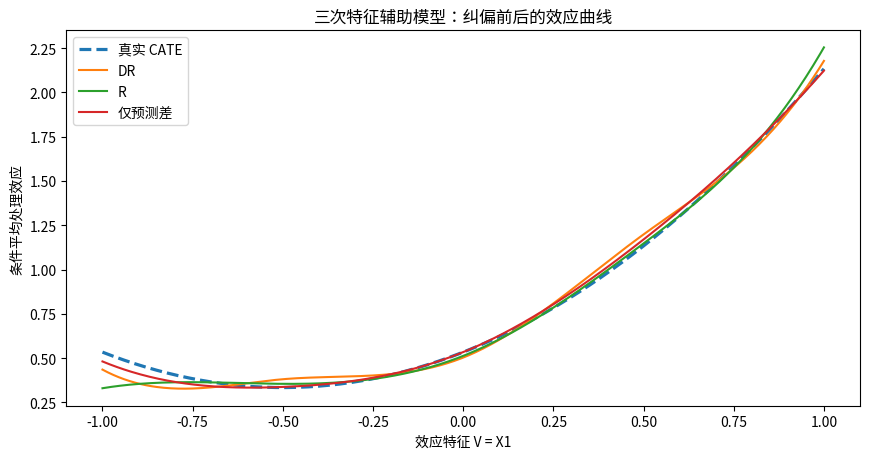

In [8]:
phi_main = effect_basis(v, "spline")
phi_test = effect_basis(v_test, "spline")
grid = np.linspace(-1, 1, 401)
phi_grid = effect_basis(grid, "spline")
tau_grid = .8+.8*grid+.8*(grid**2-1/3)
coef_main = {m: fit_final(phi_main, signal_main, m) for m in ("DR", "R")}
coef_main["仅预测差"] = np.linalg.lstsq(phi_main,
    nuisance_main["mu1"]-nuisance_main["mu0"], rcond=None)[0]
main_eval = pd.DataFrame([{"方法": m, "测试 CATE MSE": np.mean((phi_test@b-test_known["tau"])**2),
    "测试平均预测效应": (phi_test@b).mean()} for m, b in coef_main.items()])
display(main_eval.round(6))

fig, ax = plt.subplots(figsize=(8.8, 4.7))
ax.plot(grid, tau_grid, linestyle="--", linewidth=2.3, label="真实 CATE")
for m, b in coef_main.items():
    ax.plot(grid, phi_grid@b, label=m)
ax.set(xlabel="效应特征 V = X1", ylabel="条件平均处理效应",
       title="三次特征辅助模型：纠偏前后的效应曲线")
ax.legend()
fig.tight_layout()
plt.show()

默认数据下，DR 与 R 的测试 MSE 约为 0.00214 和 0.00189；仅平滑预测差的对照更小，约为 0.000568。这里两侧结果函数本来就容易用多项式表达，残差纠偏没有改善这一次拟合的函数风险。它增强的是对辅助误差的稳健性，不保证每份数据上的 MSE 都下降。

### 5. 换成通用机器学习回归器

下面用直方图梯度提升树重新学习第一阶段。第二阶段同时试两种实现：保留样条，或直接用梯度提升树。对 R 的树模型明确传入 `sample_weight=b²`，而不是把 $a/b$ 当作普通标签。所有超参数预先固定，不根据测试真值选择。[4]

这里的树是普通加权回归树的集成，不是下一篇要讨论的因果森林。仅仅把树放进因果分析流程，并没有改变树本身的统计推断方法。

,最终模型,测试 CATE MSE
0,DR / 样条,0.003373
1,R / 样条,0.002320
2,DR / 提升树,0.023558
3,R / 提升树,0.016307


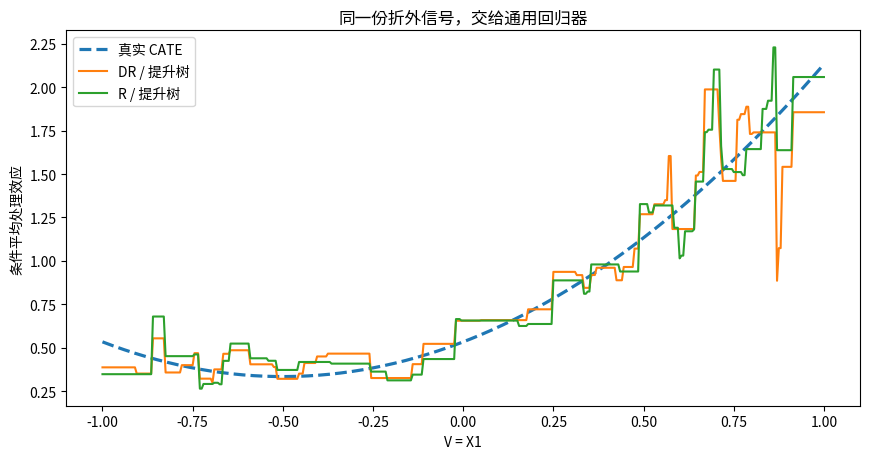

In [9]:
nuisance_boost = crossfit_nuisances(x, t, y, regressors("boost"), propensity_model(),
    folds=nuisance_main["folds"], clip=CLIP)
signal_boost = make_signals(t, y, nuisance_boost["mu0"], nuisance_boost["mu1"],
                           nuisance_boost["e"], nuisance_boost["ell"])
final_tree = HistGradientBoostingRegressor(max_iter=100, max_leaf_nodes=6,
    min_samples_leaf=60, learning_rate=.06, l2_regularization=0.,
    early_stopping=False, random_state=SEED_LEARNER)
final_dr_tree = clone(final_tree).fit(v[:, None], signal_boost["gamma"])
if np.any(signal_boost["b"] == 0):
    raise ValueError("此加权实现需要非零的处理残差；直接残差实现没有这一步除法。")
final_r_tree = clone(final_tree).fit(v[:, None], signal_boost["a"]/signal_boost["b"],
                                    sample_weight=signal_boost["w"])
boost_coefs = {m: fit_final(phi_main, signal_boost, m) for m in ("DR", "R")}
boost_preds = {
    "DR / 样条": phi_test@boost_coefs["DR"], "R / 样条": phi_test@boost_coefs["R"],
    "DR / 提升树": final_dr_tree.predict(v_test[:, None]),
    "R / 提升树": final_r_tree.predict(v_test[:, None]),
}
display(pd.DataFrame([{"最终模型": m, "测试 CATE MSE": np.mean((p-test_known["tau"])**2)}
                     for m, p in boost_preds.items()]).round(6))
fig, ax = plt.subplots(figsize=(8.8, 4.7))
ax.plot(grid, tau_grid, linestyle="--", linewidth=2.3, label="真实 CATE")
ax.plot(grid, final_dr_tree.predict(grid[:, None]), label="DR / 提升树")
ax.plot(grid, final_r_tree.predict(grid[:, None]), label="R / 提升树")
ax.set(xlabel="V = X1", ylabel="条件平均处理效应", title="同一份折外信号，交给通用回归器")
ax.legend()
fig.tight_layout()
plt.show()

在同一份提升树辅助预测下，最终样条的 DR／R 测试 MSE 约为 0.00337／0.00232；最终提升树约为 0.02356／0.01631，局部起伏更大。当前效应是光滑二次式，较少基函数已能表达它。第一阶段怎样预测结果与处理，第二阶段怎样限制效应，是两件事；更灵活的最终模型并未在这次数据中带来改善。

## 模型分析

### 1. “结果模型正确”对两种方法不是同一句话

DR 使用的是两组条件均值 $\mu_0,\mu_1$；这里的 R 直接使用 $\ell=E[Y\mid X]$。不能把它们写成同一个“结果模型”，再笼统地说一边正确即可。

先固定一个特征层：$e=0.2$、$\mu_0=1$、$\mu_1=2$，于是 $\delta=1$、$\ell=1.2$。下面不拟合模型，而是指定辅助预测的偏差，然后按处理概率精确平均。这些是总体计算，不含训练误差或 Monte Carlo 误差。

In [10]:
e0, mu00, mu10 = .2, 1., 2.
ell0, delta0 = mu00+e0*(mu10-mu00), mu10-mu00
arm = np.array([0, 1])
arm_prob = np.array([1-e0, e0])
y_arm = np.array([mu00, mu10])
error_cases = [
    ("辅助函数均正确", 0., 0.),
    ("评分正确，均值预测偏高 0.4", 0., .4),
    ("均值预测正确，评分从 0.2 改为 0.5", .3, 0.),
    ("两类预测都有上述误差", .3, .4),
]
fixed_rows = []
for name, de, dmean in error_cases:
    s = make_signals(arm, y_arm, np.full(2, mu00+dmean), np.full(2, mu10+dmean),
                     np.full(2, e0+de), np.full(2, ell0+dmean))
    dr_limit = arm_prob@s["gamma"]
    r_limit = (arm_prob@(s["a"]*s["b"]))/(arm_prob@s["w"])
    fixed_rows.append({"设定": name, "真实效应": delta0, "DR 总体目标": dr_limit,
                       "R 总体目标": r_limit})
display(pd.DataFrame(fixed_rows).round(6))

# 原书也允许 ell 由两侧预测与评分组合。这里单独检查这个不同构造。
e_mixture = .5
ell_mixture = mu00+e_mixture*(mu10-mu00)
s_mixture = make_signals(arm, y_arm, np.full(2, mu00), np.full(2, mu10),
                         np.full(2, e_mixture), np.full(2, ell_mixture))
r_mixture = (arm_prob@(s_mixture["a"]*s_mixture["b"]))/(arm_prob@s_mixture["w"])
print(f"两侧均值准确，改用 ell = mu0 + e_hat*(mu1-mu0)：R 的总体目标 = {r_mixture:.6f}")

,设定,真实效应,DR 总体目标,R 总体目标
0,辅助函数均正确,1.0,1.00,1.00
1,评分正确，均值预测偏高 0.4,1.0,1.00,1.00
2,均值预测正确，评分从 0.2 改为 0.5,1.0,1.00,0.64
3,两类预测都有上述误差,1.0,1.48,1.12


两侧均值准确，改用 ell = mu0 + e_hat*(mu1-mu0)：R 的总体目标 = 1.000000


第三行最关键：DR 仍等于 1；直接使用正确 $\ell$ 的 R 变为 0.64。R 的残差损失有正交性，但不是 DR 那种对称的“双重稳健”。第一行、第二行则说明评分正确时，两种总体计算都可以恢复该层效应。[2，第 15.1 节 DR 与 R 的误差讨论]

最后打印的值又回到了 1。这不是与第三行矛盾：它把 R 的 $\widehat\ell$ 改成了原书允许的另一种构造 $\widehat\mu_0+\widehat e(\widehat\mu_1-\widehat\mu_0)$。两侧均值完全准确时，$\widehat\ell$ 的误差与评分误差恰好关联并抵消。因此，上表第三行的结论针对“直接估计 $\ell$”这一路径，不应推广为对所有耦合构造都不可能抵消。[2，正文第 403 页]

### 2. 用误差公式看清这种区别

下面的两个恒等式是对原书目标函数的代数展开。把辅助预测视为已经固定的函数，记 $d_e=\widehat e-e$、$d_t=\widehat\mu_t-\mu_t$、$d_\ell=\widehat\ell-\ell$，并令 $s=e(1-e)$。在一个给定的完整特征层内，

$$
E[\widehat\Gamma\mid X]-\delta(X)
=d_e\left(\frac{d_1}{\widehat e}+\frac{d_0}{1-\widehat e}\right).
$$

两组均值误差都为零，或评分误差为零，右侧都为零。对 R，若此处允许任意函数，则条件最优解为

$$
f_R^*(X)=\frac{E[(T-\widehat e)(Y-\widehat\ell)\mid X]}
{E[(T-\widehat e)^2\mid X]}
=\frac{s\delta+d_ed_\ell}{s+d_e^2},
$$

所以

$$
f_R^*(X)-\delta(X)=\frac{d_ed_\ell-\delta d_e^2}{s+d_e^2}.
$$

R 的误差多了一个 $d_e^2$ 项。它仍是局部二阶项，却不会仅因为 $d_\ell=0$ 就消失。若采用上面的混合构造且两侧均值正确，则 $d_\ell=d_e\delta$，两项正好抵消。

下面让两侧均值的偏差都等于 $b$；R 的 $\ell$ 偏差也设为 $b$。两张图分别显示两种总体偏差，纵轴数值相同只是便于比较，并不表示两种方法估计的是同一个辅助函数。图中没有抽样或拟合过程。

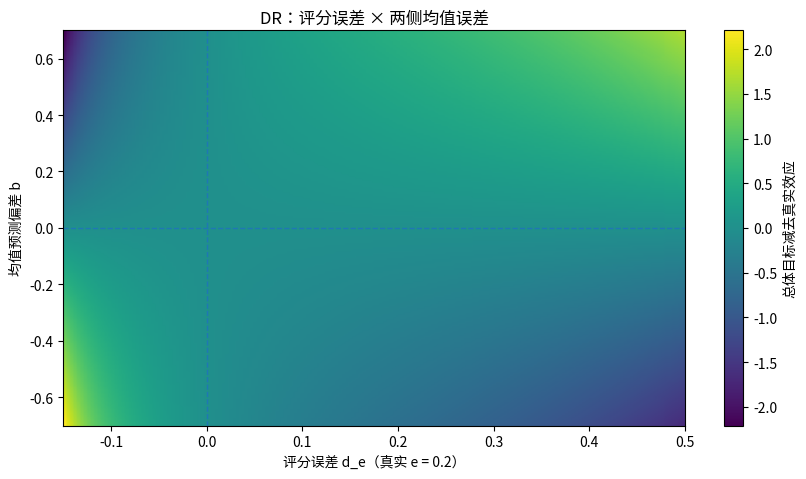

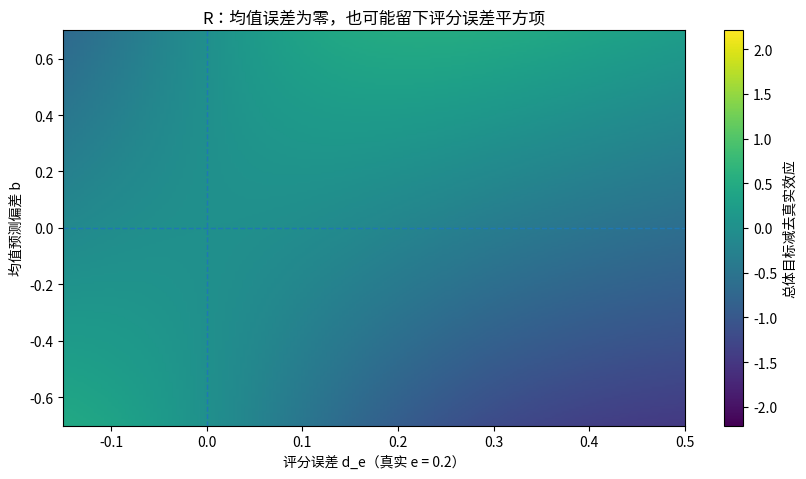

In [11]:
de_grid = np.linspace(-.15, .5, 181)
dmean_grid = np.linspace(-.7, .7, 181)
DE, DM = np.meshgrid(de_grid, dmean_grid)
phat = e0+DE
bias_dr = DE*DM*(1/phat+1/(1-phat))
bias_r = (DE*DM-delta0*DE**2)/(e0*(1-e0)+DE**2)
shared_norm = CenteredNorm(halfrange=max(np.abs(bias_dr).max(), np.abs(bias_r).max()))
for title, bias in [("DR：评分误差 × 两侧均值误差", bias_dr),
                    ("R：均值误差为零，也可能留下评分误差平方项", bias_r)]:
    fig, ax = plt.subplots(figsize=(8.6, 4.9))
    image = ax.imshow(bias, origin="lower", aspect="auto", norm=shared_norm,
        extent=[de_grid[0], de_grid[-1], dmean_grid[0], dmean_grid[-1]])
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set(xlabel="评分误差 d_e（真实 e = 0.2）", ylabel="均值预测偏差 b", title=title)
    fig.colorbar(image, ax=ax, label="总体目标减去真实效应")
    fig.tight_layout()
    plt.show()

DR 图在两条零误差轴上都没有偏差；R 图只有评分误差为零的整条轴有这个性质，另一个零偏差方向需要两类误差满足特定关系。

这些图解释的是辅助误差如何进入目标，而不是完整学习误差。原书的 CATE 风险讨论还包括第二阶段在函数空间内学习的误差，并对辅助误差的范数和学习器提出条件；不能从“误差相乘”直接推出任意机器学习模型都有有效的点态置信区间。[2，正文第 401、403 页]

### 3. 不只看一次拟合：重新生成训练数据

现在回到真正拟合的主模拟。比较线性、三次展开两种辅助结果模型，评分均使用同一个 Logistic 规格。每份数据上所有方法共享分折，第二阶段统一用无惩罚二次基函数。真实效应属于这个空间，因此这里不混入最终函数空间的目标差异。

600 人与 2,400 人各生成 150 份独立训练数据。每次都重新拟合所有辅助模型和最终模型，在从未进入训练的固定网格上评价函数误差；网格仅用于近似 $V\sim U(-1,1)$ 的平均风险，不用于挑选参数。

In [12]:
grid_mc = np.linspace(-.999, .999, 501)
phi_mc = effect_basis(grid_mc, "quadratic")
tau_mc = .8+.8*grid_mc+.8*(grid_mc**2-1/3)
mc_rows, mc_curves = [], {}
for n in SAMPLE_SIZES:
    for rep in range(N_REPEATS):
        sample, _ = make_data(n, SEED_REPEAT+10000*n+rep)
        xx, tt, yy = sample["x"], sample["t"], sample["y"]
        phi = effect_basis(xx[:, 0], "quadratic")
        for kind in ("linear", "cubic"):
            nuisance = crossfit_nuisances(xx, tt, yy, regressors(kind), propensity_model(),
                n_folds=N_FOLDS, seed=SEED_SPLIT+rep, clip=CLIP)
            s = make_signals(tt, yy, nuisance["mu0"], nuisance["mu1"], nuisance["e"], nuisance["ell"])
            for method in ("DR", "R"):
                prediction = phi_mc@fit_final(phi, s, method)
                mc_rows.append({"n": n, "rep": rep, "辅助结果模型": kind, "方法": method,
                    "MSE": np.mean((prediction-tau_mc)**2),
                    "平均预测误差": np.mean(prediction-tau_mc), "截断行数": nuisance["n_clipped"]})
                mc_curves.setdefault((n, kind, method), []).append(prediction)
mc = pd.DataFrame(mc_rows)
mc_summary_rows = []
for key, block in mc.groupby(["n", "辅助结果模型", "方法"], sort=True):
    curves = np.asarray(mc_curves[key])
    bias_squared = np.mean((curves.mean(axis=0)-tau_mc)**2)
    variance = curves.var(axis=0, ddof=0).mean()
    np.testing.assert_allclose(bias_squared+variance, block["MSE"].mean(), atol=1e-12)
    mc_summary_rows.append({"n": key[0], "辅助结果模型": key[1], "方法": key[2],
        "平均 MSE": block["MSE"].mean(), "MSE 的 MC 标准误": block["MSE"].std(ddof=1)/np.sqrt(len(block)),
        "曲线偏差平方": bias_squared, "曲线方差": variance})
mc_summary = pd.DataFrame(mc_summary_rows)
display(mc_summary.round(6))
print(f"独立训练样本总数：{len(SAMPLE_SIZES)*N_REPEATS}；单次拟合最大评分截断数：{mc['截断行数'].max()}")

,n,辅助结果模型,方法,平均 MSE,MSE 的 MC 标准误,曲线偏差平方,曲线方差
0,600,cubic,DR,0.012630,0.000822,0.000113,0.012517
1,600,cubic,R,0.010203,0.000620,0.000110,0.010094
2,600,linear,DR,0.021974,0.001862,0.000612,0.021363
3,600,linear,R,0.016235,0.001291,0.000135,0.016100
4,2400,cubic,DR,0.002499,0.000153,0.000014,0.002485
5,2400,cubic,R,0.002180,0.000136,0.000016,0.002164
6,2400,linear,DR,0.004318,0.000315,0.000062,0.004256
7,2400,linear,R,0.003467,0.000250,0.000025,0.003443


独立训练样本总数：300；单次拟合最大评分截断数：0


默认重复结果中，600 人时三次辅助模型下的 DR、R 平均 MSE 约为 0.01263、0.01020；2,400 人时约为 0.00250、0.00218。线性辅助模型的误差更大，但这组模拟中也随样本量增加而减少。评分规格正确起了作用；它不表示线性结果模型突然变成了正确模型。

“曲线偏差平方”是先在同一网格位置对重复拟合求平均，再计算与真曲线的差；不是先把每条曲线平均成一个数再平方。表中用分母为重复次数的经验方差，核对了有限次重复下的 MSE 分解。

下面的误差棒表示平均 MSE 的 $\pm1.96$ 倍 Monte Carlo 标准误，不是某位参与者的效应区间。配对差使用同一份训练数据的 R 减 DR，以免把共享数据当成独立比较。

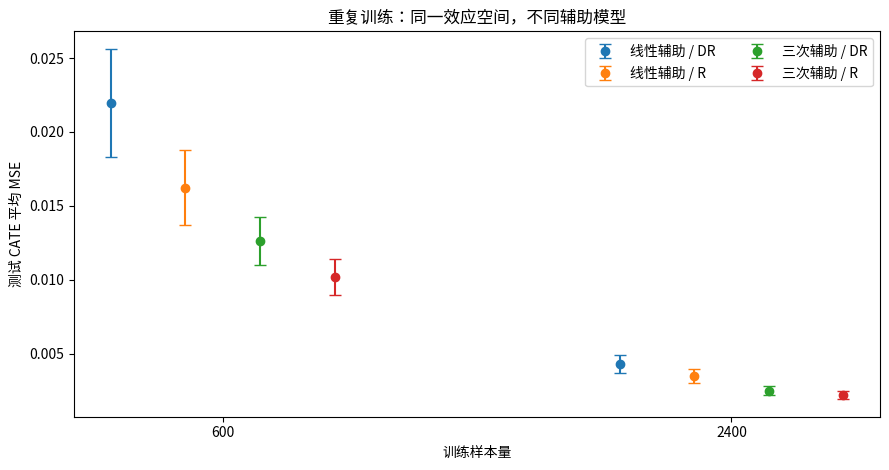

平均配对 MSE 差：R-DR    MC 标准误
n    辅助结果模型                           
600  cubic         -0.002427  0.000681
     linear        -0.005739  0.001349
2400 cubic         -0.000319  0.000074
     linear        -0.000851  0.000180

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.8))
settings = [("linear", "DR"), ("linear", "R"), ("cubic", "DR"), ("cubic", "R")]
offsets = np.linspace(-.22, .22, len(settings))
for offset, (kind, method) in zip(offsets, settings):
    block = mc_summary[(mc_summary["辅助结果模型"] == kind) & (mc_summary["方法"] == method)]
    block = block.set_index("n").loc[list(SAMPLE_SIZES)]
    ax.errorbar(np.arange(len(SAMPLE_SIZES))+offset, block["平均 MSE"],
        yerr=1.96*block["MSE 的 MC 标准误"], fmt="o", capsize=4,
        label=f"{'线性' if kind == 'linear' else '三次'}辅助 / {method}")
ax.set_xticks(np.arange(len(SAMPLE_SIZES)), [str(n) for n in SAMPLE_SIZES])
ax.set(xlabel="训练样本量", ylabel="测试 CATE 平均 MSE", title="重复训练：同一效应空间，不同辅助模型")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()
paired = mc.pivot(index=["n", "rep", "辅助结果模型"], columns="方法", values="MSE")
paired["R-DR"] = paired["R"]-paired["DR"]
paired_summary = paired["R-DR"].groupby(level=["n", "辅助结果模型"]).agg(["mean", "std", "count"])
paired_summary["MC 标准误"] = paired_summary["std"]/np.sqrt(paired_summary["count"])
display(paired_summary[["mean", "MC 标准误"]].rename(columns={"mean": "平均配对 MSE 差：R-DR"}).round(6))

这组设计里 R 的平均风险较小，但它没有覆盖“任意复杂效应”或“任意错误评分”。上一节已给出评分错设时的反例，下一节再改变最终模型允许表达的函数。

主模拟的最终参数预先固定。实际需要调参时，不能用真实 CATE 选模型，因为真实数据没有这个标签；也不能在同一批训练伪结局上选完第二阶段后，再把训练损失称为独立评价。应另留评价数据，必要时在训练部分内部嵌套第一阶段学习。后续的效应模型验证笔记再展开这些评分方法。

## 完整案例三：低重叠时，稳定不一定表示目标相同

### 1. 先去掉第一阶段误差

另外设 $V\sim U(-1,1)$，$e_k(V)=\operatorname{expit}(kV)$，

$$
\mu_0(V)=1+\sin(\pi V),\qquad \tau(V)=1+2V^2,
\qquad Y=\mu_0(V)+T\tau(V)+0.5\varepsilon.
$$

$k$ 越大，两端越难同时看到两种处理。本节直接使用真实辅助函数，目的是把重叠和最终模型的影响单独拿出来；不是一种可用于未知真实数据的拟合捷径。这里不截断真实评分，$k=6$ 时它仍严格介于 0 与 1。

同时查看 DR 标签和 R 的比值标签。R 并不保证 $a/b$ 本身很小；只有连同权重 $b^2$，或直接用残差损失，才是本篇讨论的方法。

,量,绝对误差中位数,绝对误差 99% 分位,最大绝对误差
0,DR 标签减真效应,0.3985,8.3427,90.8552
1,R 比值标签减真效应（尚未加权）,4.8287,235.3138,467.0952


样本真实评分范围：0.002508 至 0.997511；未作截断。


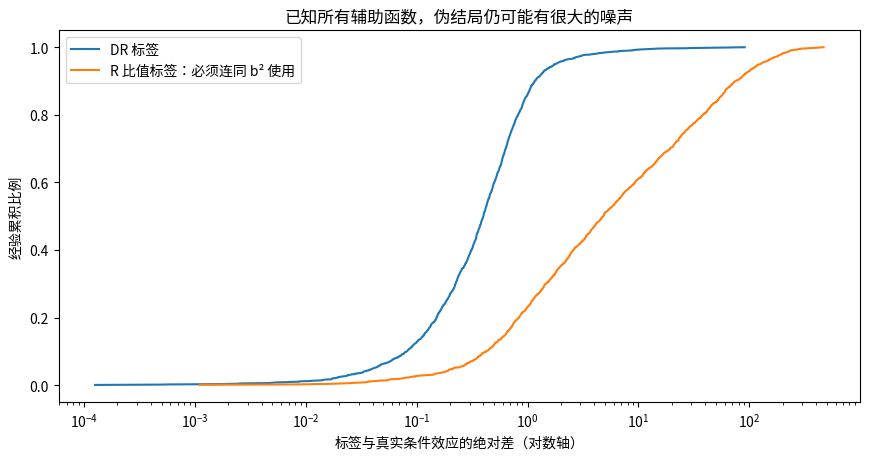

In [14]:
def low_functions(v, strength):
    v = as_vector(v, "V")
    if not np.isfinite(strength) or not 0 <= strength <= 10:
        raise ValueError("本教学实验的 strength 范围为 [0, 10]。")
    e = expit(strength*v)
    mu0, tau = 1+np.sin(np.pi*v), 1+2*v*v
    return {"mu0": mu0, "mu1": mu0+tau, "e": e, "ell": mu0+e*tau, "tau": tau}


def make_low_data(n, strength, seed):
    if not isinstance(n, int) or n < 4:
        raise ValueError("n 必须是至少为 4 的整数。")
    rng = np.random.default_rng(seed)
    vv = rng.uniform(-1, 1, n)
    truth = low_functions(vv, strength)
    tt = rng.binomial(1, truth["e"])
    yy = truth["mu0"]+tt*truth["tau"]+.5*rng.normal(size=n)
    s = make_signals(tt, yy, truth["mu0"], truth["mu1"], truth["e"], truth["ell"])
    return vv, tt, yy, truth, s

v_low, t_low, y_low, known_low, signal_low = make_low_data(N_OVERLAP, 6, SEED_OVERLAP)
q_low = signal_low["a"]/signal_low["b"]
label_diagnostics = []
for name, error in [("DR 标签减真效应", signal_low["gamma"]-known_low["tau"]),
                    ("R 比值标签减真效应（尚未加权）", q_low-known_low["tau"])]:
    label_diagnostics.append({"量": name, "绝对误差中位数": np.median(abs(error)),
        "绝对误差 99% 分位": np.quantile(abs(error), .99), "最大绝对误差": np.max(abs(error))})
display(pd.DataFrame(label_diagnostics).round(4))
print(f"样本真实评分范围：{known_low['e'].min():.6f} 至 {known_low['e'].max():.6f}；未作截断。")
fig, ax = plt.subplots(figsize=(8.8, 4.7))
for name, errors in [("DR 标签", signal_low["gamma"]-known_low["tau"]),
                     ("R 比值标签：必须连同 b² 使用", q_low-known_low["tau"])]:
    values = np.sort(abs(errors))
    ax.plot(values, np.arange(1, len(values)+1)/len(values), label=name)
ax.set_xscale("log")
ax.set(xlabel="标签与真实条件效应的绝对差（对数轴）", ylabel="经验累积比例",
       title="已知所有辅助函数，伪结局仍可能有很大的噪声")
ax.legend()
fig.tight_layout()
plt.show()

R 的比值标签可以比 DR 标签更大，因为在几乎必然接受处理的人中，$T-e$ 往往很小。但这些行的 R 权重也很小。把这一列比值单独拿去做普通回归，会把这些点放大而不减权。

### 2. 两种损失在总体上分别逼近什么？

辅助函数已知时，DR 有

$$
E[(\Gamma-f(V))^2]
=E[(\tau_V(V)-f(V))^2]+E[\operatorname{Var}(\Gamma\mid V)].
$$

第二项与 $f$ 无关，所以它逼近普通的均方误差最优函数。R 则由 $Y-\ell(X)=(T-e(X))\delta(X)+\varepsilon_Y$ 得到

$$
E[(Y-\ell(X)-(T-e(X))f(V))^2]
=E[e(X)(1-e(X))(\delta(X)-f(V))^2]+E[\varepsilon_Y^2].
$$

因此，当最终模型受限时，R 学习的是重叠加权投影，而不一定是普通投影。[2，式 (15.1.8)，正文第 404 页]

特别地，只允许常数函数时，两个目标分别是

$$
c_{\mathrm{DR}}=E[\delta(X)],\qquad
c_R=\frac{E[e(X)(1-e(X))\delta(X)]}{E[e(X)(1-e(X))]}.
$$

这正好接回本章的 IRM 与 PLR。在当前真实效应为二次式的例子中，常数空间是错设的；R 可以牺牲两端的拟合来更准确地描述中间人群。若扩展到包含真实二次式的空间，两种总体最优曲线又相同。

,最终空间,方法,总体平均拟合值,普通 MSE,重叠加权 MSE
0,constant,DR,1.666667,0.355556,0.316582
1,constant,R,1.169869,0.602364,0.069773
2,quadratic,DR,1.666667,0.000000,0.000000
3,quadratic,R,1.666667,0.000000,0.000000


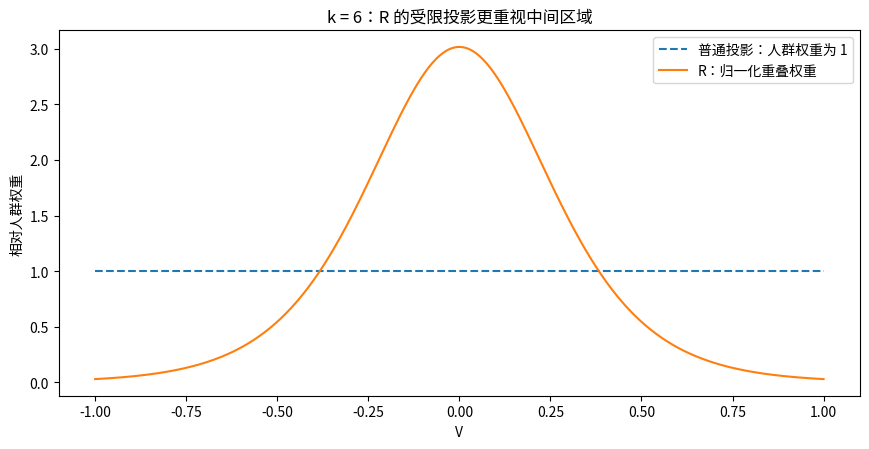

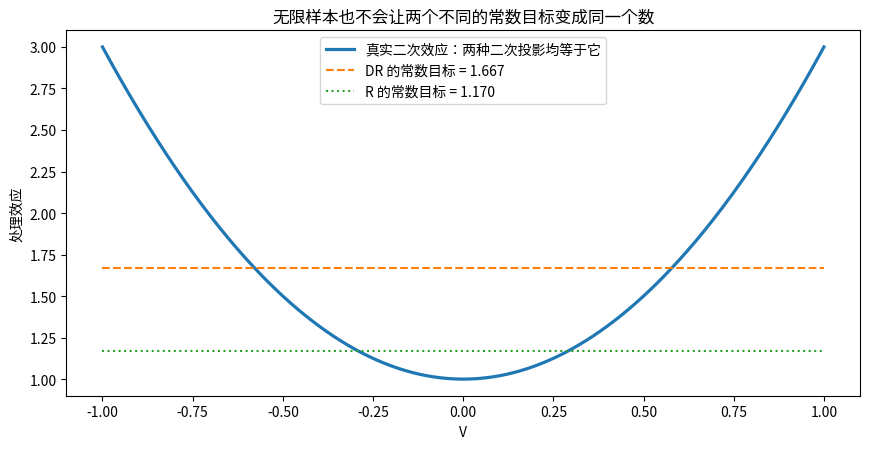

In [15]:
# Gauss-Legendre 求积仅用于算已知总体目标，不用于训练。
v_quad, probability_quad = leggauss(200)
probability_quad = probability_quad/2  # U(-1, 1) 的密度为 1/2。
truth_quad = low_functions(v_quad, 6)
variance_t_quad = truth_quad["e"]*(1-truth_quad["e"])


def population_projection(strength, kind, method):
    truth = low_functions(v_quad, strength)
    weights = probability_quad.copy()
    if method == "R":
        weights *= truth["e"]*(1-truth["e"])
    elif method != "DR":
        raise ValueError("method 必须为 DR 或 R。")
    phi = effect_basis(v_quad, kind)
    return np.linalg.lstsq(np.sqrt(weights)[:, None]*phi,
                          np.sqrt(weights)*truth["tau"], rcond=None)[0]

projection_rows = []
for kind in ("constant", "quadratic"):
    for method in ("DR", "R"):
        coeff = population_projection(6, kind, method)
        prediction = effect_basis(v_quad, kind)@coeff
        error = (prediction-truth_quad["tau"])**2
        projection_rows.append({"最终空间": kind, "方法": method,
            "总体平均拟合值": probability_quad@prediction,
            "普通 MSE": probability_quad@error,
            "重叠加权 MSE": (probability_quad*variance_t_quad)@error/(probability_quad@variance_t_quad)})
projection_table = pd.DataFrame(projection_rows)
display(projection_table.round(6))

fig, ax = plt.subplots(figsize=(8.8, 4.6))
smooth_v = np.linspace(-1, 1, 401)
smooth_low = low_functions(smooth_v, 6)
smooth_var = smooth_low["e"]*(1-smooth_low["e"])
ax.plot(smooth_v, np.ones(len(smooth_v)), linestyle="--", label="普通投影：人群权重为 1")
ax.plot(smooth_v, smooth_var/(probability_quad@variance_t_quad), label="R：归一化重叠权重")
ax.set(xlabel="V", ylabel="相对人群权重", title="k = 6：R 的受限投影更重视中间区域")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.plot(smooth_v, smooth_low["tau"], linewidth=2.3, label="真实二次效应：两种二次投影均等于它")
for method, style in [("DR", "--"), ("R", ":")]:
    c = population_projection(6, "constant", method)[0]
    ax.plot(smooth_v, np.full(len(smooth_v), c), linestyle=style,
            label=f"{method} 的常数目标 = {c:.3f}")
ax.set(xlabel="V", ylabel="处理效应", title="无限样本也不会让两个不同的常数目标变成同一个数")
ax.legend()
fig.tight_layout()
plt.show()

常数 DR 是对全体人群的效应求平均；常数 R 对中部给予较大权重，因为这里同时接受或不接受处理的机会更充分。真实效应在两端较大，所以 R 的常数目标低于普通平均。增加样本只会让估计更接近各自的目标，不会消除这个差别。

这里的“投影”指无额外惩罚、固定函数空间内的总体最优解。若加一个不消失的惩罚，还会改变目标；不能把所有带正则化的拟合值都直接当成表中的精确投影。

### 3. 重复模拟：将目标差异与抽样波动分开

分别取 $k=1$ 与 $k=6$，每次生成 2,000 人，重复 300 次。所有辅助函数仍已知，最终模型比较常数与二次式。除了对真实 CATE 的 MSE，还计算对各自总体投影的 MSE。

“平均拟合值”是将该次拟合曲线对总体特征分布求平均；对错设的常数 R，它不应改名为 ATE。图中横线是对应模型的总体目标，误差棒是重复模拟标准差，不是该样本的一条置信区间。

,k,最终空间,方法,总体平均目标,平均拟合值,重复拟合标准差,CATE_MSE,各自投影MSE
0,1,constant,DR,1.666667,1.665649,0.025223,0.356191,0.000635
1,1,constant,R,1.624718,1.624145,0.026802,0.358080,0.000716
2,1,quadratic,DR,1.666667,1.667249,0.021725,0.001675,0.001675
3,1,quadratic,R,1.666667,1.667222,0.021740,0.001672,0.001672
4,6,constant,DR,1.666667,1.675802,0.089688,0.363656,0.008101
5,6,constant,R,1.169869,1.173403,0.043528,0.600753,0.001901
6,6,quadratic,DR,1.666667,1.675293,0.088831,0.041484,0.041484
7,6,quadratic,R,1.666667,1.670387,0.086654,0.021382,0.021382


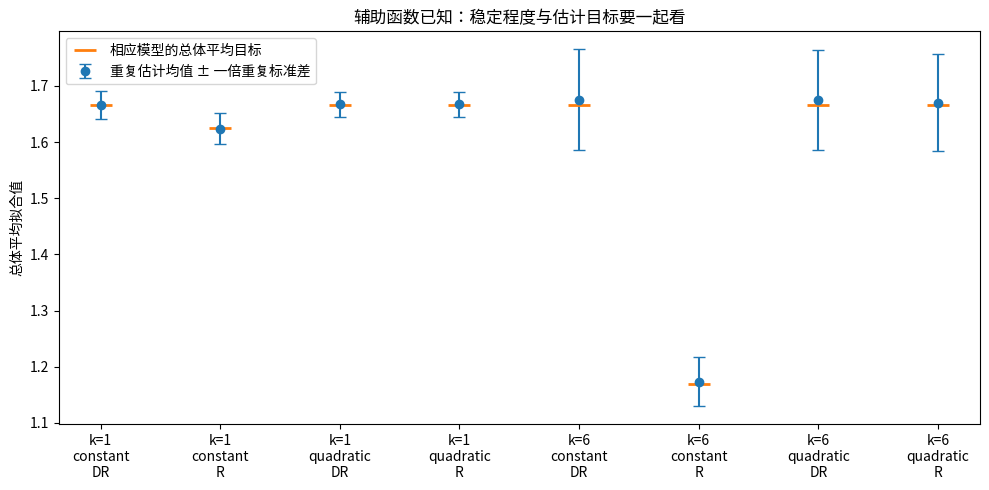

In [16]:
low_rows = []
for strength in (1, 6):
    truth_q = low_functions(v_quad, strength)
    for rep in range(N_OVERLAP_REPEATS):
        vv, tt, yy, truth, sig = make_low_data(N_OVERLAP, strength,
            SEED_OVERLAP+10000*strength+rep)
        for kind in ("constant", "quadratic"):
            phi, phi_q = effect_basis(vv, kind), effect_basis(v_quad, kind)
            for method in ("DR", "R"):
                prediction = phi_q@fit_final(phi, sig, method)
                target = phi_q@population_projection(strength, kind, method)
                low_rows.append({"k": strength, "rep": rep, "最终空间": kind, "方法": method,
                    "平均拟合值": probability_quad@prediction, "平均目标": probability_quad@target,
                    "CATE MSE": probability_quad@((prediction-truth_q["tau"])**2),
                    "投影 MSE": probability_quad@((prediction-target)**2)})
low_mc = pd.DataFrame(low_rows)
low_summary = low_mc.groupby(["k", "最终空间", "方法"]).agg(
    总体平均目标=("平均目标", "first"), 平均拟合值=("平均拟合值", "mean"),
    重复拟合标准差=("平均拟合值", "std"), CATE_MSE=("CATE MSE", "mean"),
    各自投影MSE=("投影 MSE", "mean")).reset_index()
display(low_summary.round(6))

fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(len(low_summary))
ax.errorbar(positions, low_summary["平均拟合值"], yerr=low_summary["重复拟合标准差"],
            fmt="o", capsize=4, label="重复估计均值 ± 一倍重复标准差")
ax.plot(positions, low_summary["总体平均目标"], linestyle="none", marker="_",
        markersize=16, markeredgewidth=2, label="相应模型的总体平均目标")
ax.set_xticks(positions, [f"k={r.k}\n{r.最终空间}\n{r.方法}" for r in low_summary.itertuples()])
ax.set(ylabel="总体平均拟合值", title="辅助函数已知：稳定程度与估计目标要一起看")
ax.legend()
fig.tight_layout()
plt.show()

弱重叠时，DR 标签里的少数大残差会增大方差。二次 R 使用较有信息的中间区域来估计二次曲线，因而可能更稳定；这依赖效应确实可以用二次式描述，而不是算法找回了缺失的另一组观测。

表中常数 R 的“各自投影 MSE”可以很小，同时“CATE MSE”并不小。前者说明它围绕自己的目标较稳定，后者还包含所选函数空间及人群加权带来的差异。实际解释前，必须先决定哪个目标有意义。

已知真实辅助函数是为了隔离这个现象。在真实数据中还要重新考虑第一阶段学习误差、评分边界、未测混杂和数据依赖；本节不能证明某一种方法在真实数据上更好。

## 练习

### 练习一：常数模型与权重缩放

先用主案例的同一份折外信号核对：常数 DR 是否等于 AIPW 的样本均值，常数 R 是否等于 PLR 的残差斜率？再在 12 行小表上给两种等价 R 实现都加岭惩罚，检查权重归一化后的变化。

`Ridge` 的目标为平方和加 `alpha` 乘系数平方和。若把全部权重乘以 $c$，要保持完全相同的优化问题，惩罚也要乘以 $c$；否则等于改变了相对惩罚强度。[5]

本题为方便核对，统一惩罚全部基函数系数，包括效应截距；这不是前面无惩罚主分析的设定。

In [17]:
constant_phi = effect_basis(v, "constant")
constant_dr = fit_final(constant_phi, signal_main, "DR")[0]
constant_r = fit_final(constant_phi, signal_main, "R")[0]
a_main, b_main = signal_main["a"], signal_main["b"]
aipw_mean = signal_main["gamma"].mean()
plr_slope = np.dot(a_main, b_main)/np.dot(b_main, b_main)
np.testing.assert_allclose([constant_dr, constant_r], [aipw_mean, plr_slope], atol=1e-12)
display(pd.DataFrame({"方法": ["常数 DR / AIPW", "常数 R / PLR"],
                      "最终回归": [constant_dr, constant_r], "直接公式": [aipw_mean, plr_slope]}).round(8))

alpha_ridge = .7
ridge_direct = Ridge(alpha=alpha_ridge, fit_intercept=False, solver="svd").fit(
    b_tiny[:, None]*phi_tiny, a_tiny).coef_
ridge_weighted = Ridge(alpha=alpha_ridge, fit_intercept=False, solver="svd").fit(
    phi_tiny, q_tiny, sample_weight=w_tiny).coef_
c_scale = 1/w_tiny.mean()
ridge_changed = Ridge(alpha=alpha_ridge, fit_intercept=False, solver="svd").fit(
    phi_tiny, q_tiny, sample_weight=c_scale*w_tiny).coef_
ridge_rescaled = Ridge(alpha=c_scale*alpha_ridge, fit_intercept=False, solver="svd").fit(
    phi_tiny, q_tiny, sample_weight=c_scale*w_tiny).coef_
np.testing.assert_allclose(ridge_direct, ridge_weighted, atol=1e-12)
np.testing.assert_allclose(ridge_direct, ridge_rescaled, atol=1e-12)
display(pd.DataFrame([ridge_direct, ridge_weighted, ridge_changed, ridge_rescaled],
    index=["直接残差 Ridge", "原始权重 Ridge", "只归一化权重", "权重与 alpha 同时缩放"],
    columns=["效应截距", "效应斜率"]).round(6))

,方法,最终回归,直接公式
0,常数 DR / AIPW,0.796162,0.796162
1,常数 R / PLR,0.719340,0.719340


,效应截距,效应斜率
直接残差 Ridge,0.717391,0.423423
原始权重 Ridge,0.717391,0.423423
只归一化权重,0.866142,0.563887
权重与 alpha 同时缩放,0.717391,0.423423


两种常数回归的等价关系是样本代数恒等式，不代表其人口目标总相同。当前主模拟存在异质性且评分变化，因此两个常数不能不加解释地都叫作总体 ATE。

岭回归的原始两种实现相同，单独归一化权重却改变了答案。采用通用软件时，需要检查它最小化的是总损失还是平均损失，以及是否自己缩放权重；公式形式相似，不够保证数值一致。

### 练习二：完整调整后，只按一个变量报告效应

沿用上一篇四个等比例层的结构：$X=(V,W)$，$V,W\in\{0,1\}$；$\mu_0=1+2V+4W$、$\delta=1+V+2W$，评分依次为 0.1、0.4、0.6、0.9。辅助模型知道完整的 $(V,W)$，最终模型却只允许按 $V$ 给两个数。

普通 CATE 目标为 $E[\delta(V,W)\mid V]$。R 损失在这个较小特征集下的最优解则为

$$
f_R^*(v)=\frac{E[e(X)(1-e(X))\delta(X)\mid V=v]}
{E[e(X)(1-e(X))\mid V=v]}.
$$

这是原书式 (15.1.8) 对任意 $V$ 函数的条件最小化结果。本例真实效应还依赖 $W$，因此不能套用“真实效应只依赖 $V$”的结论。下面完整枚举四个层、两种处理，共八个总体状态，以概率质量代替重复采样。

,V,W,质量,e,delta
0,0,0,0.25,0.1,1
1,0,1,0.25,0.4,3
2,1,0,0.25,0.6,2
3,1,1,0.25,0.9,4


,V,普通条件平均,DR 精确回归,重叠加权条件平均,R 精确回归
0,0,2.0,2.0,2.454545,2.454545
1,1,3.0,3.0,2.545455,2.545455


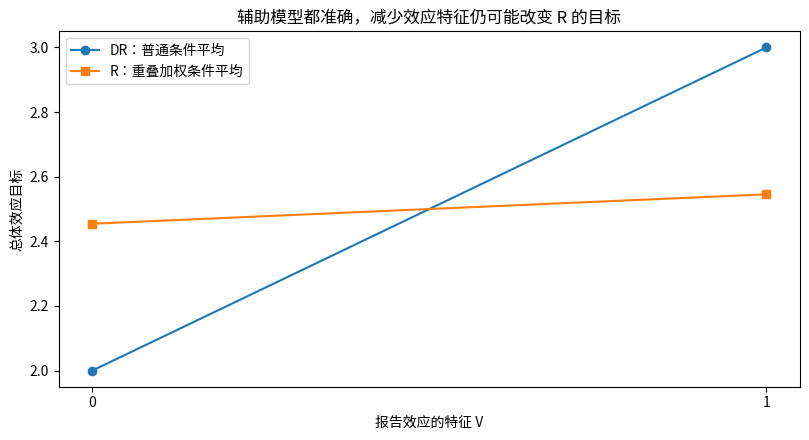

In [18]:
strata = pd.DataFrame({"V": [0, 0, 1, 1], "W": [0, 1, 0, 1],
                       "质量": [.25]*4, "e": [.1, .4, .6, .9]})
strata["mu0"] = 1+2*strata["V"]+4*strata["W"]
strata["delta"] = 1+strata["V"]+2*strata["W"]
strata["mu1"] = strata["mu0"]+strata["delta"]
strata["ell"] = strata["mu0"]+strata["e"]*strata["delta"]
expanded = strata.loc[strata.index.repeat(2)].reset_index(drop=True)
expanded["T"] = np.tile([0, 1], len(strata))
expanded["概率"] = expanded["质量"]*np.where(expanded["T"] == 1, expanded["e"], 1-expanded["e"])
expanded["Y"] = np.where(expanded["T"] == 1, expanded["mu1"], expanded["mu0"])
# 使用条件均值状态已足够精确计算这两个总体目标；不模拟残差噪声。
s_expanded = make_signals(expanded["T"], expanded["Y"], expanded["mu0"],
                          expanded["mu1"], expanded["e"], expanded["ell"])
phi_v = np.column_stack([(expanded["V"] == 0).astype(float), (expanded["V"] == 1).astype(float)])
root_mass = np.sqrt(expanded["概率"].to_numpy())
coef_dr_v = np.linalg.lstsq(root_mass[:, None]*phi_v, root_mass*s_expanded["gamma"], rcond=None)[0]
coef_r_v = np.linalg.lstsq(root_mass[:, None]*s_expanded["b"][:, None]*phi_v,
                         root_mass*s_expanded["a"], rcond=None)[0]
rows_v = []
for vv in (0, 1):
    block = strata[strata["V"] == vv]
    p = block["质量"].to_numpy()
    overlap = (block["e"]*(1-block["e"])).to_numpy()
    ordinary = np.average(block["delta"], weights=p)
    weighted = np.average(block["delta"], weights=p*overlap)
    rows_v.append({"V": vv, "普通条件平均": ordinary, "DR 精确回归": coef_dr_v[vv],
                   "重叠加权条件平均": weighted, "R 精确回归": coef_r_v[vv]})
subset_result = pd.DataFrame(rows_v)
np.testing.assert_allclose(subset_result["普通条件平均"], coef_dr_v, atol=1e-12)
np.testing.assert_allclose(subset_result["重叠加权条件平均"], coef_r_v, atol=1e-12)
display(strata[["V", "W", "质量", "e", "delta"]])
display(subset_result.round(6))

fig, ax = plt.subplots(figsize=(8.2, 4.5))
ax.plot([0, 1], coef_dr_v, marker="o", label="DR：普通条件平均")
ax.plot([0, 1], coef_r_v, marker="s", label="R：重叠加权条件平均")
ax.set_xticks([0, 1])
ax.set(xlabel="报告效应的特征 V", ylabel="总体效应目标",
       title="辅助模型都准确，减少效应特征仍可能改变 R 的目标")
ax.legend()
fig.tight_layout()
plt.show()

DR 给出 2 和 3；R 给出约 2.455 和 2.545。所有辅助函数都已知，差异不是模型训练失败，而是较小效应特征集下的人群加权不同。保留完整 $(V,W)$ 来学习一个不受限的效应函数时，这个差异才消失；或者需要额外条件，使层内权重不改变效应平均。

## 总结与适用范围

DR-Learner 先构造带结果预测与加权残差的信号，再回归到效应特征上。它把 AIPW 的平均估计扩展到了条件平均学习，但第二阶段的近似与估计误差仍然存在。

R-Learner 直接拟合残差关系，也可以写成带 $b^2$ 权重的比值标签回归。它的局部正交性减少辅助误差的一阶影响，但对直接估计的 $\ell$ 与评分，不具有和 DR 相同的对称双重稳健性。

两者的比较必须连同目标一起看：当真实效应可由所选特征和函数空间表示时，它们可以学习同一条曲线；若最终空间受限，或省略了实际存在的效应修饰变量，R 通常对应重叠加权投影。低重叠下更平稳的曲线，可能部分来自这种加权和模型外推，而不是更多反事实信息。

本篇使用独立模拟真值评价函数误差，没有把曲线起伏、伪结局标准差或 Monte Carlo 误差棒当作 CATE 置信区间。第一阶段交叉拟合也不能解决未测混杂。实际数据中的识别论证、重叠诊断与独立评价，仍需分别完成。

下一篇讨论因果树与因果森林，重点转向分裂规则、诚实估计以及效应不确定性，而不只是将普通回归器换成森林。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. 所附 `因果推断.pdf`，arXiv:2305.18793v2，2023-10-03。第 12.1 节的 AIPW 及双重稳健恒等式；第 10.3 节的条件识别。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 所附 `CausalML_book_2022.pdf`，实际扉页版本为 0.1.2，2026-05-03。第 14.1 节；第 15.1 节式 (15.1.5)–(15.1.8)、正文第 401–404 页与备注 15.1.1。本文先按 DR 信号、R 损失的顺序讲解，再用另设例子核对稳健性与投影目标；文中“第 403 页”等指正文页码，不是 PDF 页序。

[3] scikit-learn 1.8 官方文档，SplineTransformer：<https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.SplineTransformer.html>。用于固定结点、偏置基函数与外推设置的接口核对。

[4] scikit-learn 1.8 官方文档，HistGradientBoostingRegressor：<https://scikit-learn.org/1.8/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html>。用于第二阶段平方损失回归与 `sample_weight` 接口；本篇参数为教学配置，没有声称复现 EconML 或原书软件结果。

[5] scikit-learn 1.8 官方文档，Ridge：<https://scikit-learn.org/1.8/modules/generated/sklearn.linear_model.Ridge.html>。用于平方和目标、`alpha`、`fit_intercept` 与样本权重的核对。本次实际软件版本打印在初始化单元中。